In [1]:
# ============================================================
# 1. Imports and configuration
# ============================================================

import os
import random
import warnings

warnings.filterwarnings("ignore")

import cv2
import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2 as transforms
import torchvision

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from torch.utils.tensorboard import SummaryWriter

sns.set(font_scale=1.4)
sns.set_style("white")
plt.rc("font", size=14)

# Reproducibility
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
else:
    device = torch.device("cpu")

print(f"Device: {device}")

# ImageNet stats for EfficientNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Training config
IMG_SIZE = 256
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
EPOCHS = 1000
PATIENCE = 30

print("Configuration")
print(f"  Image size: {IMG_SIZE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Patience: {PATIENCE}")
print(f"  Max epochs: {EPOCHS}")

# Paths – adjust to your structure
PATH = "/kaggle/input/dataset-cleaned/"
TRAIN_IMG_DIR = PATH + "train_data_cleaned/images"   # contains img_0001.png, ...
TRAIN_MASK_DIR = PATH + "train_data_cleaned/masks"   # contains mask_0001.png, ...
TEST_IMG_DIR = PATH + "test_data"     # contains img_XXXX.png
TRAIN_LABELS_CSV = PATH + "train_data_cleaned/train_labels.csv" # mapping image name to class label
MODELS_DIR = "models"
os.makedirs(MODELS_DIR, exist_ok=True)

2025-12-06 11:41:27.404655: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765021287.842068      71 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765021287.953216      71 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Device: cuda
Configuration
  Image size: 256
  Batch size: 64
  Learning rate: 0.001
  Patience: 10
  Max epochs: 1000


In [2]:
# ============================================================
# 2. Utility functions
# ============================================================

def mask_to_bbox(mask: np.ndarray):
    """
    From a single channel mask compute tight bounding box.

    Args:
        mask: 2D numpy array, non zero pixels are foreground

    Returns:
        (x1, y1, x2, y2) in absolute pixel coordinates
    """
    ys, xs = np.where(mask > 0)
    if len(xs) == 0 or len(ys) == 0:
        # fall back to full image if mask empty
        h, w = mask.shape
        return 0, 0, w - 1, h - 1
    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()
    return x1, y1, x2, y2


def spearman_rho(predictions, targets):
    """
    Spearman rank correlation between two vectors.

    Predictions and targets can be numpy arrays or tensors.
    Computed over flattened coordinates.
    """
    if isinstance(predictions, np.ndarray):
        predictions = torch.from_numpy(predictions)
    if isinstance(targets, np.ndarray):
        targets = torch.from_numpy(targets)

    predictions = predictions.float().flatten()
    targets = targets.float().flatten()

    def rank(x):
        sorted_indices = torch.argsort(x)
        ranks = torch.argsort(sorted_indices) + 1
        return ranks.float()

    r_pred = rank(predictions)
    r_tgt = rank(targets)

    diff_pred = r_pred - r_pred.mean()
    diff_tgt = r_tgt - r_tgt.mean()

    cov = (diff_pred * diff_tgt).mean()
    std_pred = torch.sqrt((diff_pred ** 2).mean())
    std_tgt = torch.sqrt((diff_tgt ** 2).mean())

    return cov / (std_pred * std_tgt + 1e-8)

In [3]:
# ============================================================
# 3. Data loading – localisation from masks
# ============================================================

def load_localisation_data(img_dir, mask_dir, img_dim):
    """
    Load images and corresponding masks, compute bounding boxes.

    Assumes:
      - image files named like img_0001.png
      - mask files named like mask_0001.png
    """

    image_files = sorted(
        [f for f in os.listdir(img_dir) if f.lower().endswith((".png", ".jpg", ".jpeg"))]
    )

    images = []
    boxes = []

    for fname in image_files:
        img_path = os.path.join(img_dir, fname)
        img = cv2.imread(img_path)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (img_dim, img_dim))

        # build mask name from image name
        # img_0001.png -> mask_0001.png
        base = fname.replace("img_", "")
        mask_name = f"mask_{base}"
        mask_path = os.path.join(mask_dir, mask_name)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise FileNotFoundError(f"Mask not found for {fname}: {mask_path}")
        mask = cv2.resize(mask, (img_dim, img_dim), interpolation=cv2.INTER_NEAREST)

        x1, y1, x2, y2 = mask_to_bbox(mask)
        h, w = mask.shape
        bbox = [
            x1 / w,
            y1 / h,
            x2 / w,
            y2 / h,
        ]  # normalised to [0,1]

        images.append(img)
        boxes.append(bbox)

    images = np.array(images)
    boxes = np.array(boxes, dtype=np.float32)

    print(f"Localisation data loaded: {len(images)} images")
    print(f"Image shape: {images[0].shape}")
    return images, boxes


X_loc, y_boxes = load_localisation_data(TRAIN_IMG_DIR, TRAIN_MASK_DIR, IMG_SIZE)

Localisation data loaded: 1262 images
Image shape: (256, 256, 3)


In [4]:
# ============================================================
# 4. Data loading – classification from CSV
# ============================================================

from sklearn.preprocessing import LabelEncoder

def load_classification_data(img_dir, labels_csv, img_dim,
                             img_col='sample_index',
                             label_col='label'):
    """
    Load images and string labels from a CSV.

    Returns:
        X: np.array of images (N, H, W, C)
        y: np.array of string labels (N,)
    """
    df = pd.read_csv(labels_csv)

    images = []
    labels = []

    for _, row in df.iterrows():
        fname = str(row[img_col])
        label = str(row[label_col])    # keep as string

        img_path = os.path.join(img_dir, fname)
        img = cv2.imread(img_path)
        if img is None:
            continue

        # center crop to square
        dim = min(img.shape[:-1])
        img = img[(img.shape[0]-dim)//2:(img.shape[0]+dim)//2,
                  (img.shape[1]-dim)//2:(img.shape[1]+dim)//2]
        img = cv2.resize(img, (img_dim, img_dim))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        images.append(img)
        labels.append(label)

    return np.array(images), np.array(labels)


# Load classification data as images + string labels
X_cls, y_cls = load_classification_data(TRAIN_IMG_DIR, TRAIN_LABELS_CSV, IMG_SIZE)

# Encode string labels to integers
label_encoder = LabelEncoder()
y_cls_encoded = label_encoder.fit_transform(y_cls)

# number of classes and mapping int -> name
num_classes = len(label_encoder.classes_)
class_names = list(label_encoder.classes_)  # e.g. ["HER2(+)", "Luminal A", ...]
print("Classes:", class_names)

Classes: ['HER2(+)', 'Luminal A', 'Luminal B', 'Triple negative']


In [5]:
from sklearn.preprocessing import LabelEncoder

# y_cls are strings like 'Triple negative', 'Luminal A', etc.
label_encoder = LabelEncoder()
y_cls_int = label_encoder.fit_transform(y_cls)   # shape (N,)

# numeric label -> name mapping
num_to_labels = {i: lab for i, lab in enumerate(label_encoder.classes_)}

print("Classes:", num_to_labels)

Classes: {0: 'HER2(+)', 1: 'Luminal A', 2: 'Luminal B', 3: 'Triple negative'}


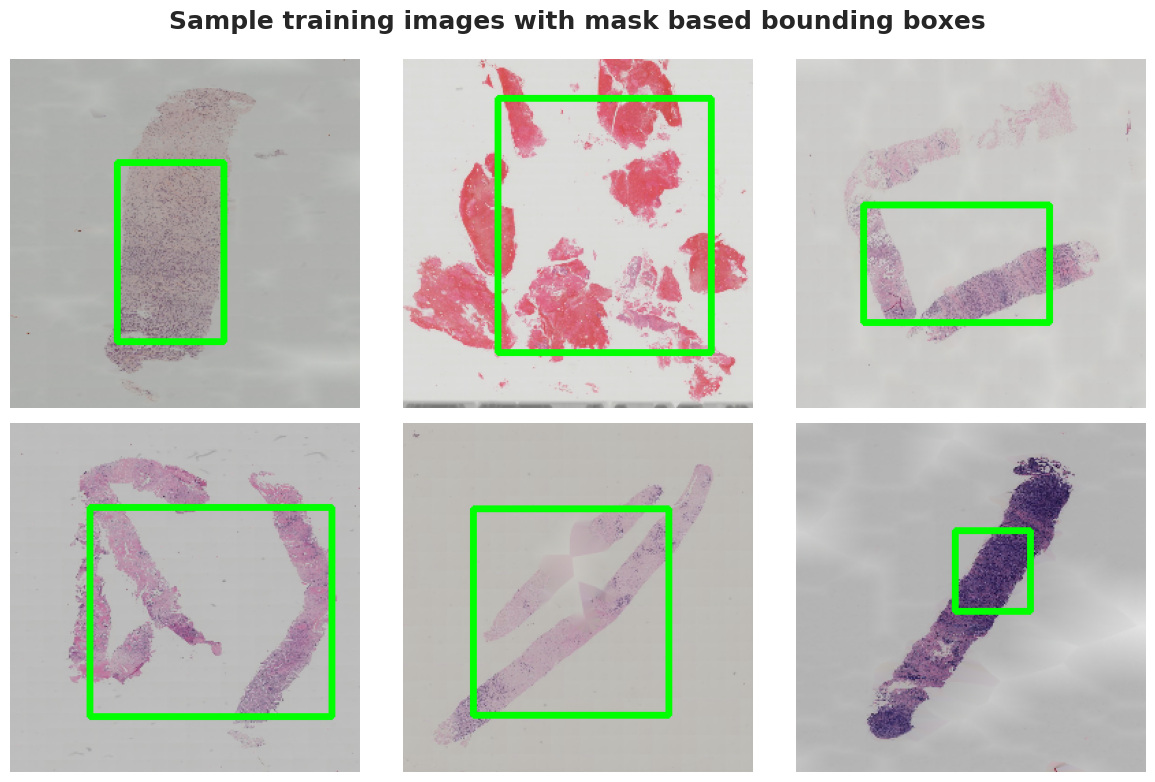

In [6]:
# ============================================================
# 5. Visualisation helper
# ============================================================

def visualize_samples_with_boxes(images, boxes, num_samples=6):
    num_samples = min(num_samples, len(images))
    indices = np.random.choice(len(images), num_samples, replace=False)

    rows = 2
    cols = (num_samples + 1) // 2
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    plt.suptitle("Sample training images with mask based bounding boxes",
                 fontsize=18, fontweight="bold")

    for i, idx in enumerate(indices):
        ax = axes[i]
        img = images[idx].copy()
        box = boxes[idx]
        h, w, _ = img.shape

        x1, y1, x2, y2 = box
        x1, y1, x2, y2 = int(x1 * w), int(y1 * h), int(x2 * w), int(y2 * h)

        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 3)
        ax.imshow(img)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


visualize_samples_with_boxes(X_loc, y_boxes, num_samples=6)

In [7]:
# ============================================================
# 6. Dataset classes and DataLoaders
# ============================================================

class BoxDataset(Dataset):
    """
    Dataset for bounding box regression.

    images: numpy array (N, H, W, C)
    boxes: numpy array (N, 4) normalised coordinates
    """

    def __init__(self, images, boxes, augmentation=None):
        self.images = torch.from_numpy(images).float().permute(0, 3, 1, 2)
        self.boxes = torch.from_numpy(boxes).float()
        self.augmentation = augmentation
        self.normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx].clone()
        box = self.boxes[idx].clone()

        if self.augmentation is not None:
            img = self.augmentation(img)

        img = self.normalize(img)
        return img, box


class ClassificationArrayDataset(Dataset):
    """
    Dataset for classification using preloaded numpy images and labels.
    labels must already be integer encoded.
    """

    def __init__(self, images, labels, augmentation=None):
        self.images = torch.from_numpy(images).float().permute(0, 3, 1, 2)
        self.labels = torch.from_numpy(labels).long()  # expects numeric labels
        self.augmentation = augmentation
        self.normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx].clone()
        lbl = self.labels[idx].clone()

        if self.augmentation is not None:
            img = self.augmentation(img)

        img = self.normalize(img)
        return img, lbl


# ------------------------------------------------------------
# train/val split for localisation
# ------------------------------------------------------------
X_loc_train, X_loc_val, y_box_train, y_box_val = train_test_split(
    X_loc,
    y_boxes,
    test_size=0.2,
    random_state=SEED,
)

# ------------------------------------------------------------
# train/val split for classification (stratified on encoded labels)
# ------------------------------------------------------------
X_cls_train, X_cls_val, y_cls_train, y_cls_val = train_test_split(
    X_cls,
    y_cls_encoded,
    test_size=0.2,
    random_state=SEED,
    stratify=y_cls_encoded,
)

print("Localisation split:", len(X_loc_train), "train", len(X_loc_val), "val")
print("Classification split:", len(X_cls_train), "train", len(X_cls_val), "val")

# ------------------------------------------------------------
# augmentation
# ------------------------------------------------------------
train_aug = transforms.Compose([transforms.RandomHorizontalFlip(p=0.5)])

# ------------------------------------------------------------
# DataLoaders
# ------------------------------------------------------------
train_box_loader = DataLoader(
    BoxDataset(X_loc_train, y_box_train, augmentation=train_aug),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

val_box_loader = DataLoader(
    BoxDataset(X_loc_val, y_box_val),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

train_cls_loader = DataLoader(
    ClassificationArrayDataset(X_cls_train, y_cls_train, augmentation=train_aug),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

val_cls_loader = DataLoader(
    ClassificationArrayDataset(X_cls_val, y_cls_val),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

print("Regression batches:", len(train_box_loader), "train", len(val_box_loader), "val")
print("Classification batches:", len(train_cls_loader), "train", len(val_cls_loader), "val")

Localisation split: 1009 train 253 val
Classification split: 1009 train 253 val
Regression batches: 16 train 4 val
Classification batches: 16 train 4 val


In [8]:
# ============================================================
# 7. Models
# ============================================================

class BoxRegressorModel(nn.Module):
    """
    Bounding box regressor on top of EfficientNetB0.
    Predicts 4 normalised coordinates: x1, y1, x2, y2.
    """

    def __init__(self, dropout_rate=0.5):
        super().__init__()
        self.backbone = torchvision.models.efficientnet_b0(
            weights=torchvision.models.EfficientNet_B0_Weights.IMAGENET1K_V1
        )
        for p in self.backbone.parameters():
            p.requires_grad = False

        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(in_features, 4),
        )

    def forward(self, x):
        return self.backbone(x)


class ClassifierModel(nn.Module):
    """
    Image classifier based on EfficientNetB0.
    """

    def __init__(self, num_classes, dropout_rate=0.5):
        super().__init__()
        self.backbone = torchvision.models.efficientnet_b0(
            weights=torchvision.models.EfficientNet_B0_Weights.IMAGENET1K_V1
        )
        for p in self.backbone.parameters():
            p.requires_grad = False

        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(in_features, num_classes),
        )

    def forward(self, x):
        return self.backbone(x)


box_model = BoxRegressorModel().to(device)
cls_model = ClassifierModel(num_classes=num_classes).to(device)

print("Box regressor parameters:", sum(p.numel() for p in box_model.parameters()))
print("Classifier parameters:", sum(p.numel() for p in cls_model.parameters()))

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 141MB/s] 


Box regressor parameters: 4012672
Classifier parameters: 4012672


In [9]:
# ============================================================
# 8. Training helpers – localisation
# ============================================================

def train_box_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    loss_sum = 0.0
    for img, box in loader:
        img = img.to(device)
        box = box.to(device)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            pred = model(img)
            loss = criterion(pred, box)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        loss_sum += loss.item() * img.size(0)

    return loss_sum / len(loader.dataset)


def val_box_epoch(model, loader, criterion):
    model.eval()
    loss_sum = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for img, box in loader:
            img = img.to(device)
            box = box.to(device)

            with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
                pred = model(img)
                loss = criterion(pred, box)

            loss_sum += loss.item() * img.size(0)
            all_preds.append(pred.cpu().numpy())
            all_targets.append(box.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    rho = float(spearman_rho(all_preds, all_targets))
    return loss_sum / len(loader.dataset), rho


def fit_box_regressor(model, train_loader, val_loader, epochs, criterion, optimizer,
                      scaler, patience, model_name):
    history = {"train_loss": [], "val_loss": [], "val_spearman": []}
    best_loss = float("inf")
    patience_counter = 0
    best_epoch = 0

    print(f"Training box regressor: {model_name}")

    for epoch in range(1, epochs + 1):
        train_loss = train_box_epoch(model, train_loader, criterion, optimizer, scaler)
        val_loss, val_rho = val_box_epoch(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_spearman"].append(val_rho)

        if epoch == 1 or epoch % 5 == 0:
            print(
                f"Epoch {epoch:3d}/{epochs} | "
                f"Train MSE {train_loss:.4f} | "
                f"Val MSE {val_loss:.4f} | "
                f"Val Spearman {val_rho:.4f}"
            )

        if val_loss < best_loss:
            best_loss = val_loss
            best_epoch = epoch
            torch.save(model.state_dict(), os.path.join(MODELS_DIR, f"{model_name}.pt"))
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    print(f"Best val MSE {best_loss:.4f} at epoch {best_epoch}")
    model.load_state_dict(torch.load(os.path.join(MODELS_DIR, f"{model_name}.pt")))
    return model, history

In [15]:
# ============================================================
# 9. Training helpers – classification
# ============================================================

def train_cls_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    loss_sum = 0.0
    acc_list = []

    for img, lbl in loader:
        img = img.to(device)
        lbl = lbl.to(device)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            out = model(img)
            loss = criterion(out, lbl)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        loss_sum += loss.item() * img.size(0)
        preds = out.argmax(dim=1).cpu().numpy()
        acc_list.append(accuracy_score(lbl.cpu().numpy(), preds))

    return loss_sum / len(loader.dataset), float(np.mean(acc_list))


def val_cls_epoch(model, loader, criterion):
    """
    Validate classifier for one epoch.

    Returns:
        avg_loss, avg_accuracy, macro_f1
    """
    model.eval()
    loss_sum = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for img, lbl in loader:
            img, lbl = img.to(device), lbl.to(device)

            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                out = model(img)
                loss = criterion(out, lbl)

            loss_sum += loss.item() * img.size(0)

            preds = out.argmax(dim=1).cpu().numpy()
            all_preds.append(preds)
            all_targets.append(lbl.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    val_acc = accuracy_score(all_targets, all_preds)
    val_f1 = f1_score(all_targets, all_preds, average="macro")

    return loss_sum / len(loader.dataset), val_acc, val_f1


def fit_classifier(model, train_loader, val_loader, epochs, criterion, optimizer,
                   scaler, patience, model_name):
    history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': [],
    'val_f1': []          # new
}
    best_f1 = -1.0
    patience_counter = 0
    best_epoch = 0

    print(f"Training classifier: {model_name}")

    for epoch in range(1, epochs + 1):
        # Training phase
        train_loss, train_acc = train_cls_epoch(model, train_loader, criterion, optimizer, scaler)

        # Validation phase
        val_loss, val_acc, val_f1 = val_cls_epoch(model, val_loader, criterion)

        # Record history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)



        # Print progress
        if epoch % 5 == 0 or epoch == 1:
            print(
                f"Epoch {epoch:3d}/{epochs} | "
                f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
                f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}"
            )

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_epoch = epoch
            torch.save(model.state_dict(), os.path.join(MODELS_DIR, f"{model_name}.pt"))
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    print(f"Best val F1 {best_f1:.4f} at epoch {best_epoch}")
    model.load_state_dict(torch.load(os.path.join(MODELS_DIR, f"{model_name}.pt")))
    return model, history

In [11]:
# ============================================================
# 10. Train box regressor
# ============================================================

box_optimizer = torch.optim.Adam(box_model.parameters(), lr=LEARNING_RATE)
box_criterion = nn.MSELoss()
scaler = torch.amp.GradScaler(enabled=(device.type == "cuda"))

box_model, box_history = fit_box_regressor(
    model=box_model,
    train_loader=train_box_loader,
    val_loader=val_box_loader,
    epochs=EPOCHS,
    criterion=box_criterion,
    optimizer=box_optimizer,
    scaler=scaler,
    patience=PATIENCE,
    model_name="efficientnet_box_regressor",
)

Training box regressor: efficientnet_box_regressor
Epoch   1/1000 | Train MSE 0.1678 | Val MSE 0.1033 | Val Spearman 0.4193
Epoch   5/1000 | Train MSE 0.0728 | Val MSE 0.0558 | Val Spearman 0.6953
Epoch  10/1000 | Train MSE 0.0522 | Val MSE 0.0483 | Val Spearman 0.6982
Epoch  15/1000 | Train MSE 0.0432 | Val MSE 0.0408 | Val Spearman 0.7297
Epoch  20/1000 | Train MSE 0.0403 | Val MSE 0.0411 | Val Spearman 0.7204
Epoch  25/1000 | Train MSE 0.0393 | Val MSE 0.0378 | Val Spearman 0.7378
Epoch  30/1000 | Train MSE 0.0351 | Val MSE 0.0371 | Val Spearman 0.7316
Epoch  35/1000 | Train MSE 0.0347 | Val MSE 0.0343 | Val Spearman 0.7342
Epoch  40/1000 | Train MSE 0.0332 | Val MSE 0.0332 | Val Spearman 0.7384
Epoch  45/1000 | Train MSE 0.0321 | Val MSE 0.0308 | Val Spearman 0.7358
Epoch  50/1000 | Train MSE 0.0295 | Val MSE 0.0317 | Val Spearman 0.7371
Epoch  55/1000 | Train MSE 0.0289 | Val MSE 0.0303 | Val Spearman 0.7474
Epoch  60/1000 | Train MSE 0.0276 | Val MSE 0.0305 | Val Spearman 0.7364


In [17]:
# ============================================================
# 11. Train classifier (frozen backbone)
# ============================================================

cls_optimizer = torch.optim.Adam(cls_model.parameters(), lr=LEARNING_RATE)
cls_criterion = nn.CrossEntropyLoss()

cls_model, cls_history = fit_classifier(
    model=cls_model,
    train_loader=train_cls_loader,
    val_loader=val_cls_loader,
    epochs=EPOCHS,
    criterion=cls_criterion,
    optimizer=cls_optimizer,
    scaler=scaler,
    patience=30,
    model_name="efficientnet_classifier",
)

Training classifier: efficientnet_classifier
Epoch   1/1000 | Train Loss: 1.0611 | Train Acc: 0.5231 | Val Loss: 1.3888 | Val Acc: 0.3597 | Val F1: 0.3473
Epoch   5/1000 | Train Loss: 1.0765 | Train Acc: 0.5453 | Val Loss: 1.3604 | Val Acc: 0.3834 | Val F1: 0.3587
Epoch  10/1000 | Train Loss: 1.0499 | Train Acc: 0.5400 | Val Loss: 1.3639 | Val Acc: 0.3755 | Val F1: 0.3501
Epoch  15/1000 | Train Loss: 1.0604 | Train Acc: 0.5435 | Val Loss: 1.3757 | Val Acc: 0.3755 | Val F1: 0.3498
Epoch  20/1000 | Train Loss: 1.0791 | Train Acc: 0.5367 | Val Loss: 1.3663 | Val Acc: 0.3715 | Val F1: 0.3495
Epoch  25/1000 | Train Loss: 1.0507 | Train Acc: 0.5507 | Val Loss: 1.3723 | Val Acc: 0.3794 | Val F1: 0.3424
Epoch  30/1000 | Train Loss: 1.0694 | Train Acc: 0.5336 | Val Loss: 1.3747 | Val Acc: 0.3794 | Val F1: 0.3520
Epoch  35/1000 | Train Loss: 1.0692 | Train Acc: 0.5432 | Val Loss: 1.3666 | Val Acc: 0.3636 | Val F1: 0.3475
Epoch  40/1000 | Train Loss: 1.0682 | Train Acc: 0.5521 | Val Loss: 1.4430 

In [18]:
# ============================================================
# 12. Optional fine tuning (unfreeze last blocks)
# ============================================================

def unfreeze_last_blocks(model, num_blocks=3):
    """
    Unfreeze last num_blocks of EfficientNet features for fine tuning.
    """
    for param in model.backbone.features[-num_blocks:].parameters():
        param.requires_grad = True

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print("Unfrozen last", num_blocks, "blocks")
    print(f"Total params: {total_params:,}")
    print(f"Trainable params: {trainable_params:,}")
    print(f"Trainable percentage: {100 * trainable_params / total_params:.1f}%")
    return model


cls_model = unfreeze_last_blocks(cls_model, num_blocks=3)

ft_optimizer = torch.optim.Adam(cls_model.parameters(), lr=1e-4)
ft_criterion = nn.CrossEntropyLoss()

cls_model, ft_history = fit_classifier(
    model=cls_model,
    train_loader=train_cls_loader,
    val_loader=val_cls_loader,
    epochs=EPOCHS,
    criterion=ft_criterion,
    optimizer=ft_optimizer,
    scaler=scaler,
    patience=5,
    model_name="efficientnet_classifier_finetuned",
)

Unfrozen last 3 blocks
Total params: 4,012,672
Trainable params: 3,160,864
Trainable percentage: 78.8%
Training classifier: efficientnet_classifier_finetuned
Epoch   1/1000 | Train Loss: 1.0785 | Train Acc: 0.5358 | Val Loss: 1.4241 | Val Acc: 0.3755 | Val F1: 0.3486
Epoch   5/1000 | Train Loss: 0.8082 | Train Acc: 0.6868 | Val Loss: 1.3811 | Val Acc: 0.4387 | Val F1: 0.4040
Epoch  10/1000 | Train Loss: 0.5661 | Train Acc: 0.8060 | Val Loss: 1.4473 | Val Acc: 0.4308 | Val F1: 0.4037
Early stopping at epoch 10
Best val F1 0.4040 at epoch 5


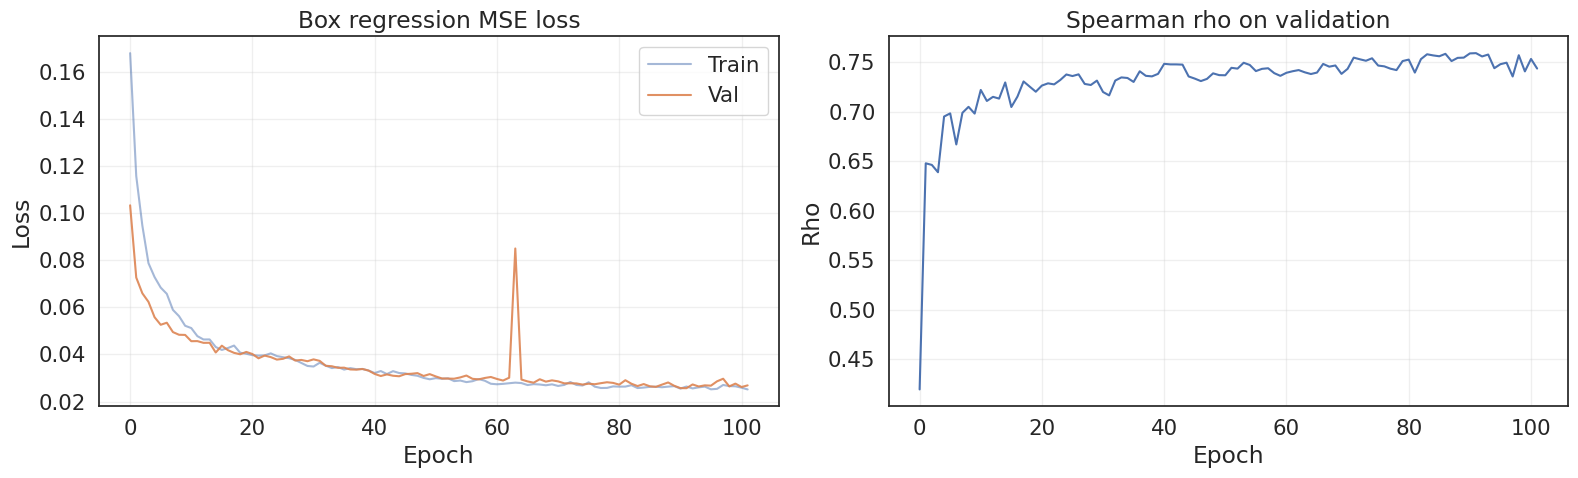

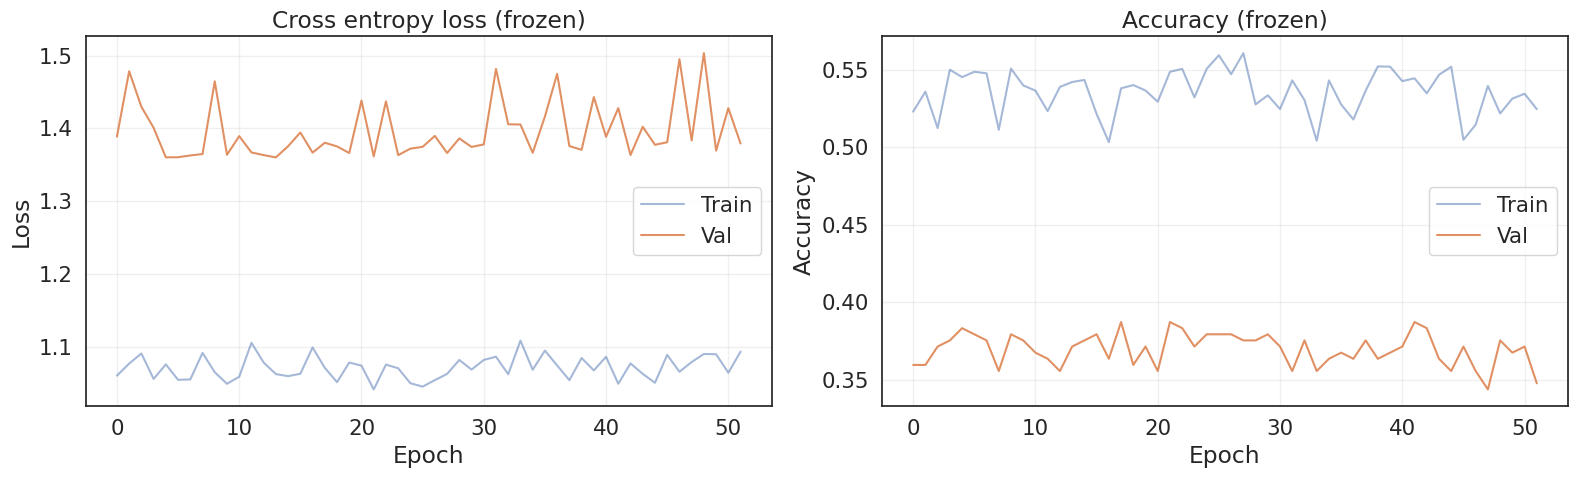

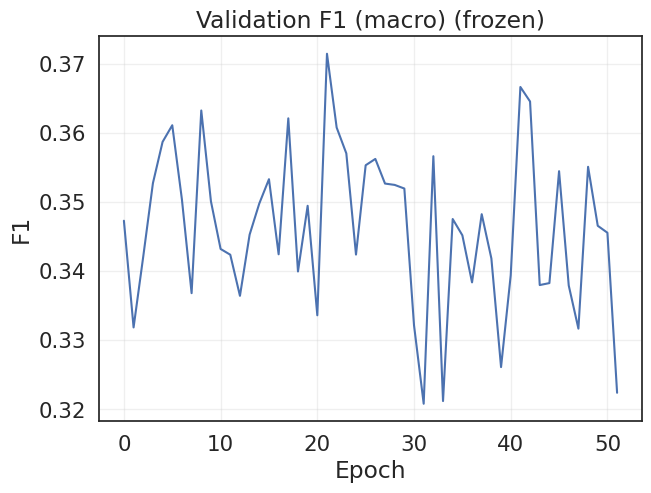

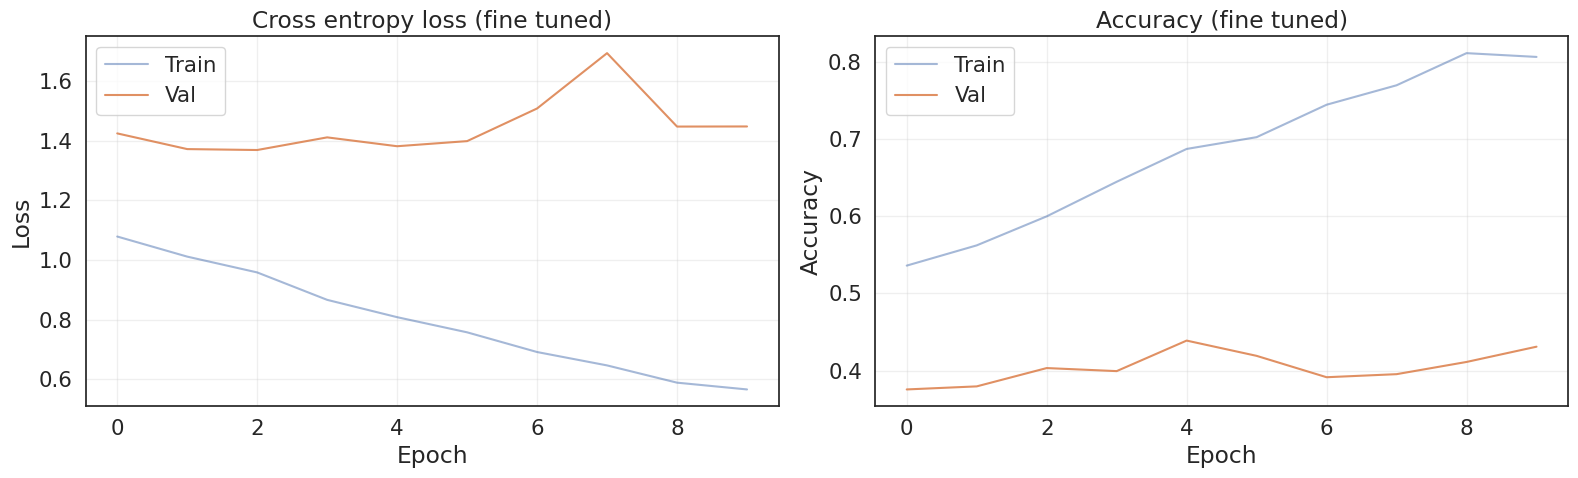

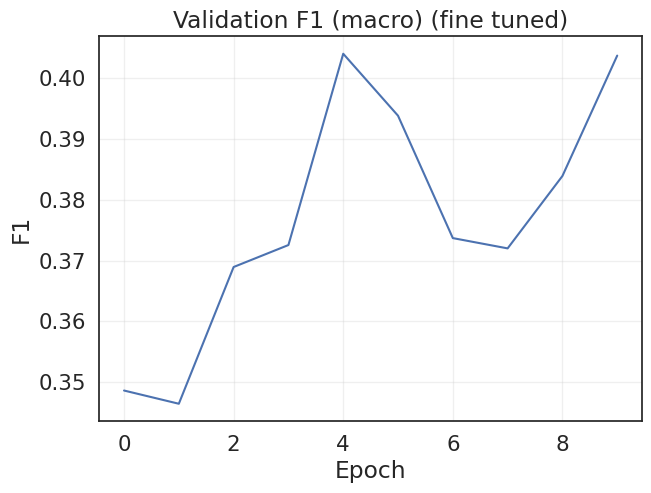

In [19]:
# ============================================================
# 13. Plot training curves
# ============================================================

def plot_history_box(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    ax1.plot(history["train_loss"], label="Train", alpha=0.5)
    ax1.plot(history["val_loss"], label="Val", alpha=0.9)
    ax1.set_title("Box regression MSE loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(history["val_spearman"])
    ax2.set_title("Spearman rho on validation")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Rho")
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_history_cls(history, title_suffix=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    ax1.plot(history["train_loss"], label="Train", alpha=0.5)
    ax1.plot(history["val_loss"], label="Val", alpha=0.9)
    ax1.set_title(f"Cross entropy loss{title_suffix}")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(history["train_acc"], label="Train", alpha=0.5)
    ax2.plot(history["val_acc"], label="Val", alpha=0.9)
    ax2.set_title(f"Accuracy{title_suffix}")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # F1 plot for this specific history
    plt.figure(figsize=(7, 5))
    plt.plot(history["val_f1"])
    plt.title(f"Validation F1 (macro){title_suffix}")
    plt.xlabel("Epoch")
    plt.ylabel("F1")
    plt.grid(alpha=0.3)
    plt.show()


plot_history_box(box_history)
plot_history_cls(cls_history, title_suffix=" (frozen)")
plot_history_cls(ft_history, title_suffix=" (fine tuned)")

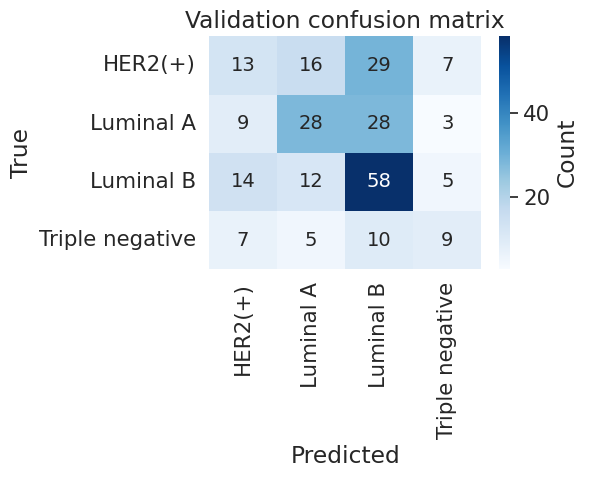

In [20]:
# ============================================================
# 14. Confusion matrix on validation
# ============================================================

def plot_confusion_matrix_model(model, loader, class_names):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for img, lbl in loader:
            img = img.to(device)
            lbl = lbl.to(device)
            out = model(img)
            preds = out.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(lbl.cpu().numpy())

    cm = confusion_matrix(all_targets, all_preds)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        cbar_kws={"label": "Count"},
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Validation confusion matrix")
    plt.tight_layout()
    plt.show()


plot_confusion_matrix_model(cls_model, val_cls_loader, class_names)

In [28]:
# ============================================================
# 15. Test set inference (classification + localisation)
# ============================================================

def load_test_images(img_dir, img_dim):
    # only keep real images, ignore mask_XXXX.png
    files = sorted(
        [
            f for f in os.listdir(img_dir)
            if f.lower().endswith((".png", ".jpg", ".jpeg")) and f.startswith("img_")
        ]
    )
    images = []
    names = []
    for fname in files:
        img_path = os.path.join(img_dir, fname)
        img = cv2.imread(img_path)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (img_dim, img_dim))
        images.append(img)
        names.append(fname)
    images = np.array(images)
    return images, names

X_test_raw, test_names = load_test_images(TEST_IMG_DIR, IMG_SIZE)
print("Loaded test images:", len(X_test_raw))

transform_test = transforms.Compose([
    # For submission block keep Resize if you need fixed size:
    # transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=False),  # <- scale=False here
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Keep test tensor on CPU
X_test_tensor = torch.stack(
    [transform_test(Image.fromarray(img)) for img in X_test_raw]
)
print("Test tensor shape:", X_test_tensor.shape)

cls_model.eval()
box_model.eval()

cls_probs_list = []
box_preds_list = []

BATCH_SIZE_TEST = BATCH_SIZE  # or set a specific value like 32

with torch.no_grad():
    for start in range(0, len(X_test_tensor), BATCH_SIZE_TEST):
        end = start + BATCH_SIZE_TEST
        batch = X_test_tensor[start:end].to(device)

        with torch.amp.autocast(
            device_type=device.type,
            enabled=(device.type == "cuda"),
        ):
            cls_logits = cls_model(batch)
            box_batch = box_model(batch)

        cls_probs_list.append(torch.softmax(cls_logits, dim=1).cpu().numpy())
        box_preds_list.append(box_batch.cpu().numpy())

cls_probs = np.concatenate(cls_probs_list, axis=0)
box_preds = np.concatenate(box_preds_list, axis=0)

print("Inference done on test set.")

Loaded test images: 954
Test tensor shape: torch.Size([954, 3, 256, 256])
Inference done on test set.


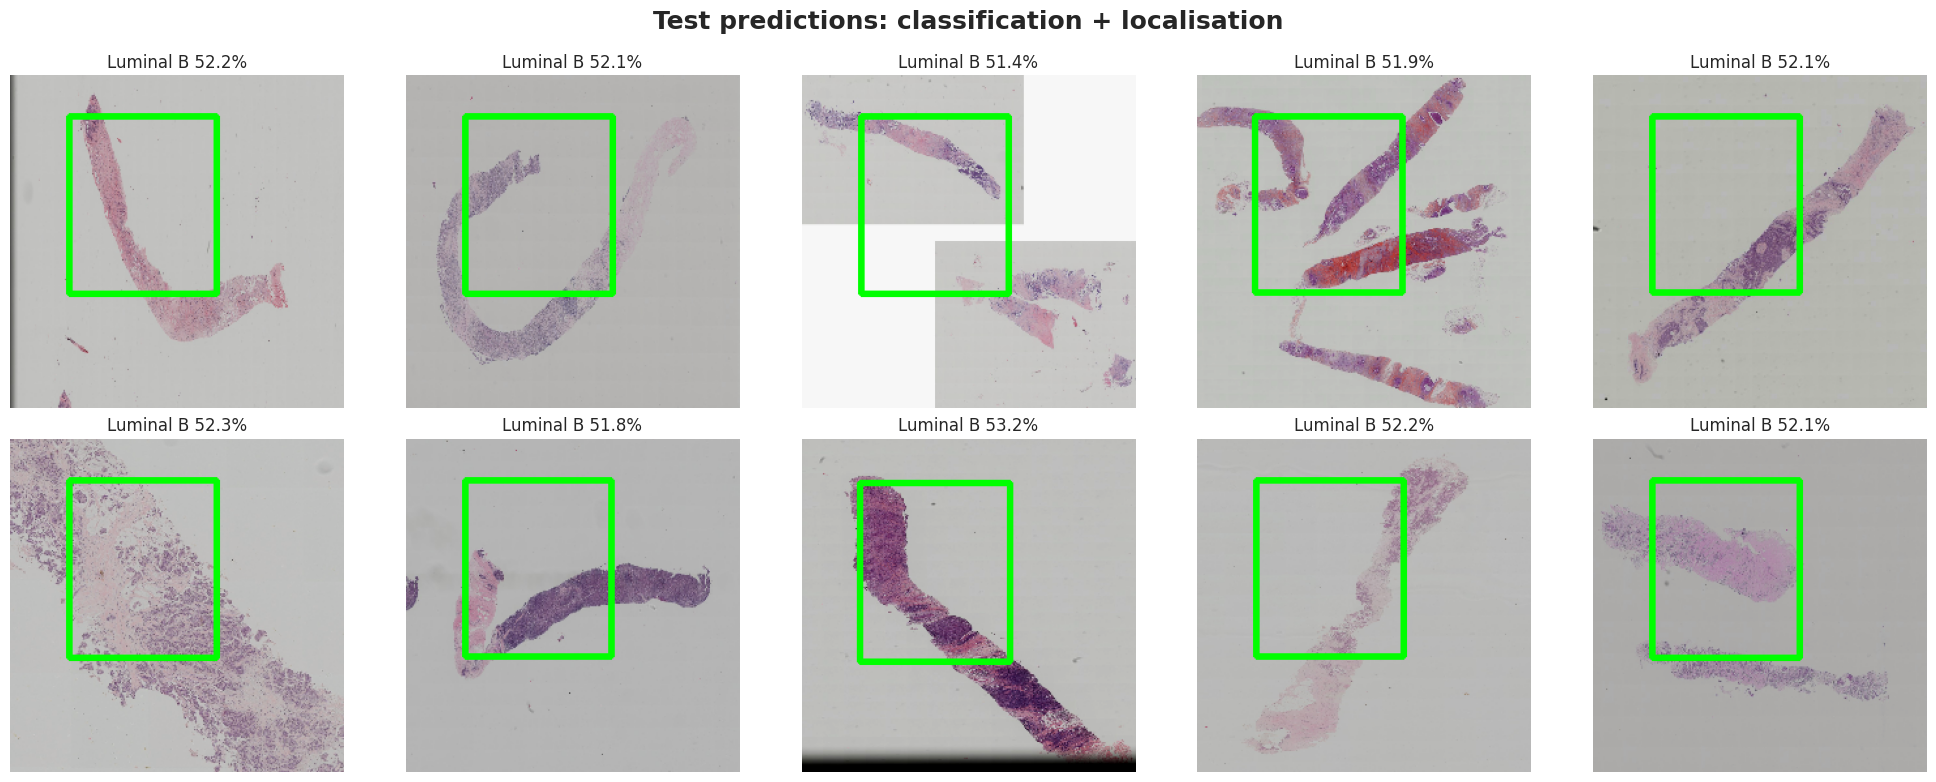

In [22]:
# ============================================================
# 16. Visualise combined predictions
# ============================================================

def visualize_test_predictions(images, cls_probs, box_preds, class_names, max_images=10):
    num_img = len(images)
    n = min(max_images, num_img)
    rows = 2
    cols = (n + 1) // 2
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    plt.suptitle("Test predictions: classification + localisation",
                 fontsize=18, fontweight="bold")

    for i in range(n):
        ax = axes[i]
        img = images[i].copy()
        h, w, _ = img.shape

        bx = box_preds[i]
        x1 = int(bx[0] * w)
        y1 = int(bx[1] * h)
        x2 = int(bx[2] * w)
        y2 = int(bx[3] * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 3)

        lbl_idx = int(np.argmax(cls_probs[i]))
        conf = float(cls_probs[i][lbl_idx] * 100)
        lbl_name = class_names[lbl_idx]

        ax.imshow(img)
        ax.set_title(f"{lbl_name} {conf:.1f}%", fontsize=12)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


visualize_test_predictions(X_test_raw, cls_probs, box_preds, class_names, max_images=10)

In [29]:
# ============================================================
# Submission generation (classification)
# ============================================================

SUBMISSION_CSV = "submission.csv"

# For submission: work directly from the files in TEST_IMG_DIR.
# Ensure:
# - only img_XXXX.png (ignore masks)
# - all resized to IMG_SIZE
# - same normalization style as training
transform_test = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),           # fix H,W
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=False),    # match training (0–255)
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Only real images, no masks
test_files = sorted([
    f for f in os.listdir(TEST_IMG_DIR)
    if f.lower().endswith((".png", ".jpg", ".jpeg")) and f.startswith("img_")
])

print("Number of test images used in submission:", len(test_files))

cls_model.eval()
rows = []
BATCH_SIZE_SUB = 64

with torch.no_grad():
    for start in range(0, len(test_files), BATCH_SIZE_SUB):
        end = start + BATCH_SIZE_SUB
        batch_files = test_files[start:end]

        batch_imgs = []
        for fname in batch_files:
            img = Image.open(os.path.join(TEST_IMG_DIR, fname)).convert("RGB")
            batch_imgs.append(transform_test(img))

        batch_tensor = torch.stack(batch_imgs).to(device)

        with torch.amp.autocast(
            device_type=device.type,
            enabled=(device.type == "cuda"),
        ):
            logits = cls_model(batch_tensor)

        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = probs.argmax(axis=1)

        # map integer predictions back to original strings
        labels_str = label_encoder.inverse_transform(preds)

        for fname, lab in zip(batch_files, labels_str):
            rows.append({
                "sample_index": fname,   # exactly like train_labels.csv
                "label": lab,            # e.g. "Triple negative"
            })

sub_df = pd.DataFrame(rows)
sub_df.to_csv(SUBMISSION_CSV, index=False)
print("Saved submission to", SUBMISSION_CSV)
print(sub_df.head())
print("Submission shape:", sub_df.shape)

Number of test images used in submission: 954
Saved submission to submission.csv
   sample_index      label
0  img_0000.png  Luminal A
1  img_0001.png  Luminal B
2  img_0002.png  Luminal B
3  img_0003.png    HER2(+)
4  img_0004.png    HER2(+)
Submission shape: (954, 2)
